# Regularization (Ridge/Lasso) + Project Proposal Sprint

<hr>

<center>
<div>
<img src="https://raw.githubusercontent.com/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/main/notebooks/figures/mgmt_474_ai_logo_02-modified.png" width="200"/>
</div>
</center>

# <center><a class="tocSkip"></center>
# <center>QM47400 Predictive Analytics</center>
# <center>Professor: Davi Moreira </center>

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/davi-moreira/2026Summer_predictive_analytics_purdue_MGMT474/blob/main/notebooks/nb05_regularization_project_proposal_instructor.ipynb)

---

## Learning Objectives

By the end of this notebook, you will be able to:

1. Explain *why* regularization is needed when feature dimensionality grows — in particular, when polynomial features break unregularized linear regression.
2. Fit Ridge regression with different alpha values and interpret how penalty strength trades off bias and variance.
3. Fit Lasso regression and interpret how it shrinks coefficients toward zero — performing automatic feature selection.
4. Compare four models side-by-side (Baseline Linear, Polynomial + OLS, Polynomial + Ridge, Polynomial + Lasso) and read the results through a bar-plot visualization.
5. Draft the first milestone of your course project using the template at the end of this notebook.

---


> **📋 Participation Reminder:** This notebook contains **2 PAUSE-AND-DO exercises**. You are expected to complete all exercises before submitting your notebook.

---

## 💼 Why This Matters: When 44 Features Beat Your Model Senseless

In the previous notebook, HomeValue Analytics tried to squeeze more accuracy out of its pricing model by expanding from 8 original features to 44 polynomial features (squares and pairwise interactions). The training R² went up — flexibility always fits training data more tightly — but the validation R² *collapsed* to a large negative value. The model was worse than predicting the mean for every tract.

The root cause: **multicollinearity**. With 44 polynomial features, many carry overlapping information (`MedInc × AveRooms` shares variance with both `MedInc` and `AveRooms`). Unregularized `LinearRegression` produces wildly unstable coefficients on correlated features. They fit training noise perfectly and extrapolate disastrously to unseen tracts.

The fix is to add a **penalty on coefficient magnitudes** to the linear regression objective. That is what **regularization** does. Two flavours dominate in practice:

- **Ridge regression** shrinks all coefficients toward zero proportionally (L2 penalty).
- **Lasso regression** shrinks some coefficients to *exactly* zero (L1 penalty), performing automatic feature selection.

Both are designed for exactly the problem we just saw. Today's notebook walks through how they work, what they fix, and — importantly — what they *do not* fully fix on HomeValue's specific dataset.

> **Today's focus:** Rescuing the polynomial feature space from catastrophic overfit using Ridge and Lasso, then drafting your first project milestone.

---


In [12]:
# Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import warnings

warnings.filterwarnings('ignore')
pd.set_option('display.precision', 4)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (10, 6)
RANDOM_SEED = 474
np.random.seed(RANDOM_SEED)
print("✓ Setup complete!")


✓ Setup complete!


**Reading the output:**

The `Setup complete!` confirmation means all imports loaded successfully. This notebook adds two regularization-specific classes to HomeValue's modeling toolkit: **Ridge** (L2 penalty) and **Lasso** (L1 penalty). Both sit in `sklearn.linear_model` alongside the `LinearRegression` you already know, and both take a single key hyperparameter called `alpha` that controls how strongly coefficients are penalized.

**Why this matters:** Regularization is the standard rescue for models that break under multicollinearity or high feature dimensionality — exactly the situation we ran into with the 44-feature polynomial expansion in the previous notebook. We will sweep a handful of alpha values manually for each technique and pick the one that maximises validation R², mirroring the C-value sweep pattern you will see again when we move to logistic regression.

---


## 1. Load Data

We load the same California Housing dataset and apply the identical 60/20/20 split with `RANDOM_SEED = 474`. Because the splits match the previous notebooks exactly — the same **12,384 training tracts**, **4,128 validation tracts**, and **4,128 locked test tracts** — any change in performance can be attributed solely to the new regularization techniques introduced here, not to data differences.

The test set remains locked; all tuning uses the validation partition.

> 💡 **Gemini Prompt:** "Load the California Housing dataset using sklearn fetch_california_housing with as_frame=True. Separate features (X) from the target MedHouseVal (y), then do a 60/20/20 train/val/test split using two sequential train_test_split calls with random_state=RANDOM_SEED. Print the sizes of each set."
>
> **After running, verify:**
> - Train set is \~60%, validation \~20%, test \~20% of total rows
> - X has 8 feature columns (MedInc, HouseAge, AveRooms, etc.)
> - y contains median house values (continuous target)> - All numerical outputs use standard decimal format — no scientific notation


In [13]:
california = fetch_california_housing(as_frame=True)
df = california.frame
X = df.drop(columns=['MedHouseVal'])
y = df['MedHouseVal']

X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.20, random_state=RANDOM_SEED)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.25, random_state=RANDOM_SEED)

print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)} (locked)")

Train: 12384 | Val: 4128 | Test: 4128 (locked)


**Reading the output:**

The printed split summary shows roughly **12,384 training**, **4,128 validation**, and **4,128 test** tracts — identical to previous notebooks. Consistency across notebooks is critical: it means the Ridge and Lasso results we compute here are directly comparable to the plain linear regression (\~R² 0.60, \~USD 53k MAE) and polynomial models (\~R² 0.68) from earlier, since they are evaluated on the exact same 4,128 validation tracts.

**Key takeaway:** Never change your random seed or split strategy mid-project. Doing so invalidates all prior comparisons and makes it impossible to tell whether performance changed because of the model or because of the data partition.

---

## 2. Recap: The Polynomial Disaster We Are Here to Rescue

Before we introduce regularization, let us reproduce the failure from the previous notebook so the before-and-after story is concrete. We fit two models: the 8-feature baseline (our benchmark) and the 44-feature polynomial expansion with unregularized `LinearRegression`. If everything holds, the 8-feature baseline will land near the \~0.62 validation R² we saw before, and the polynomial + OLS combination will collapse into strongly negative territory.

If you see validation R² worse than zero, the model is literally worse than predicting the mean `MedHouseVal` for every tract. This is HomeValue's benchmark of *failure* — and it is exactly the problem we will try to fix in the rest of this notebook.


> 💡 **Gemini Prompt:** "Fit two models side by side. First, a Pipeline with `StandardScaler` and `LinearRegression` as the 8-feature baseline. Second, a Pipeline with `PolynomialFeatures(degree=2, include_bias=False)`, then `StandardScaler`, then `LinearRegression` — the 44-feature polynomial + OLS. For each, print the train R², validation R², and validation MAE. Also print the feature count for the polynomial pipeline. Warn the user if the polynomial validation R² is negative."
>
> **After running, verify:**
> - Baseline validation R² is around 0.62
> - Polynomial + OLS validation R² is strongly negative (confirming the catastrophe)
> - Feature count expands from 8 to 44
> - A warning is printed when validation R² is negative
> - All numerical outputs use standard decimal format — no scientific notation


In [14]:
# Baseline 8-feature linear model — the bar to clear
baseline_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])
baseline_pipeline.fit(X_train, y_train)

baseline_train_r2 = baseline_pipeline.score(X_train, y_train)
baseline_val_r2 = baseline_pipeline.score(X_val, y_val)
baseline_val_mae = mean_absolute_error(y_val, baseline_pipeline.predict(X_val))

print("=== BASELINE LINEAR (8 features, no regularization) ===")
print(f"Train R²: {baseline_train_r2:.4f}")
print(f"Val R²:   {baseline_val_r2:.4f}")
print(f"Val MAE:  {baseline_val_mae:.4f}")
print()

# Polynomial + unregularized Linear — the disaster
poly_ols_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('regressor', LinearRegression())
])
poly_ols_pipeline.fit(X_train, y_train)

poly_ols_train_r2 = poly_ols_pipeline.score(X_train, y_train)
poly_ols_val_r2 = poly_ols_pipeline.score(X_val, y_val)
poly_ols_val_mae = mean_absolute_error(y_val, poly_ols_pipeline.predict(X_val))
n_features_poly = poly_ols_pipeline.named_steps['poly'].transform(X_train[:1]).shape[1]

print("=== POLYNOMIAL (deg=2) + UNREGULARIZED LINEAR ===")
print(f"Train R²: {poly_ols_train_r2:.4f}")
print(f"Val R²:   {poly_ols_val_r2:.4f}")
print(f"Val MAE:  {poly_ols_val_mae:.4f}")
print(f"Features: {n_features_poly} (originals + squares + pairwise products)")
print()

if poly_ols_val_r2 < 0:
    print("⚠️  Polynomial + OLS validation R² is NEGATIVE — worse than predicting the mean.")
    print("   This is the problem we will try to fix with Ridge and Lasso below.")


=== BASELINE LINEAR (8 features, no regularization) ===
Train R²: 0.6035
Val R²:   0.6169
Val MAE:  0.5257

=== POLYNOMIAL (deg=2) + UNREGULARIZED LINEAR ===
Train R²: 0.6846
Val R²:   -185.3208
Val MAE:  0.7697
Features: 44 (originals + squares + pairwise products)

⚠️  Polynomial + OLS validation R² is NEGATIVE — worse than predicting the mean.
   This is the problem we will try to fix with Ridge and Lasso below.


**Reading the output:**

The comparison is stark. The 8-feature baseline achieves a validation R² of roughly **\~0.62** with a small overfit gap — a solid, generalizable model. The 44-feature polynomial + OLS combination posts a higher *training* R² (the model fits the training data more tightly) but its *validation* R² collapses into strongly negative territory. A negative R² literally means the model predicts the validation tracts worse than simply guessing the mean of `MedHouseVal` for every one of them.

This is the catastrophic failure we need to rescue. In the sections that follow, we introduce Ridge and Lasso — two forms of *regularization* that add a penalty on coefficient magnitudes to the linear regression objective. Ridge shrinks all coefficients proportionally; Lasso shrinks some to exactly zero. Both try to constrain the unstable coefficients that unregularized OLS produces on 44 correlated features. How well do they each succeed? That is what we are about to find out.

---


## 3. Ridge Regression: L2 Penalty on Coefficient Magnitudes

Ridge regression changes the objective function from:

$$\min_w \|y - Xw\|^2$$

to:

$$\min_w \|y - Xw\|^2 + \alpha \sum_i w_i^2$$

The new term, $\alpha \sum_i w_i^2$, is the **L2 penalty**. It grows as the coefficients $w_i$ grow, so the optimizer is pushed toward solutions with smaller coefficients. The tuning parameter $\alpha$ controls the strength of the penalty:

- **$\alpha = 0$**: no penalty — Ridge reduces to plain `LinearRegression`
- **small $\alpha$**: mild shrinkage
- **large $\alpha$**: aggressive shrinkage — all coefficients are pushed toward zero

The key consequence: Ridge *stabilizes* the coefficients when features are highly correlated. Instead of two correlated features fighting over one large coefficient, Ridge spreads the weight between them at smaller magnitudes.

Instead of using an automated alpha selector, we sweep a few alpha values manually and compare their validation performance using the same 60/20/20 split we have used throughout the course. This mirrors the C-value sweep you will see in the logistic-regression notebook: for each candidate alpha we fit the model on `X_train` and measure generalization on `X_val`, then pick the alpha that maximises validation R².


> 💡 **Gemini Prompt:** "For alpha in [1.0, 10.0, 100.0, 1000.0, 10000.0], fit a Pipeline with `PolynomialFeatures(degree=2, include_bias=False)`, `StandardScaler`, and `Ridge(alpha=alpha)` on `X_train`, `y_train`. Compute train R², validation R², and validation MAE for each alpha. Collect results into a DataFrame with columns alpha, Train_R2, Val_R2, Val_MAE. Print the table and identify the best alpha by validation R². Then create a 3-panel bar plot (Train R², Val R², Val MAE) across the alpha values — use y-axis limits of [-2, 1] on the Val R² panel to handle strongly negative values, and annotate off-chart bars in red."
>
> **After running, verify:**
> - Table has 5 rows covering all alpha values
> - At small alpha the validation R² is strongly negative
> - At very large alpha (10000) validation R² climbs into positive territory but stays below the baseline
> - The best alpha row is printed at the bottom
> - Bar plot clearly shows validation R² climbing as alpha grows
> - All numerical outputs use standard decimal format — no scientific notation


=== RIDGE ALPHA SWEEP (polynomial features) ===
  alpha  Train_R2   Val_R2  Val_MAE
    1.0    0.6654 -13.7273   0.5685
   10.0    0.6587  -2.0602   0.5291
  100.0    0.6471  -0.5959   0.5179
 1000.0    0.6162  -0.2365   0.5293
10000.0    0.5301   0.4966   0.5899

✓ Best alpha by validation R²: 10000.0 (Val R² = 0.4966)


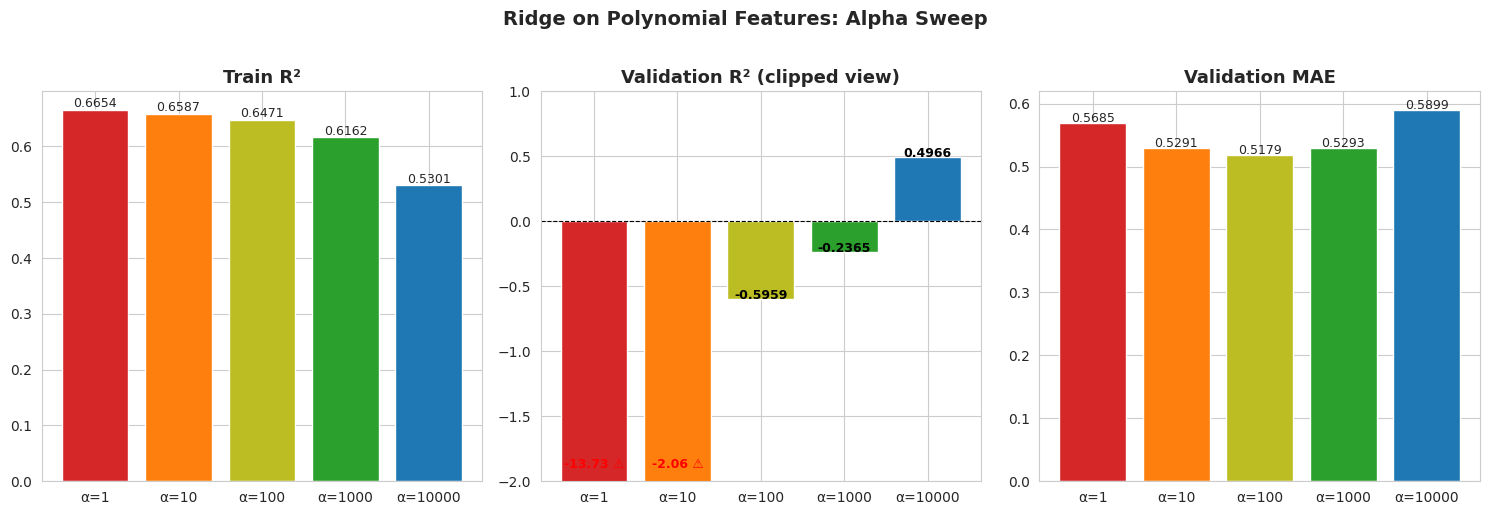

In [15]:
# Ridge alpha sweep on polynomial features
alphas_ridge = [1.0, 10.0, 100.0, 1000.0, 10000.0]
ridge_results = []

for alpha in alphas_ridge:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])
    pipe.fit(X_train, y_train)
    ridge_results.append({
        'alpha': alpha,
        'Train_R2': pipe.score(X_train, y_train),
        'Val_R2': pipe.score(X_val, y_val),
        'Val_MAE': mean_absolute_error(y_val, pipe.predict(X_val)),
    })

ridge_df = pd.DataFrame(ridge_results)
print("=== RIDGE ALPHA SWEEP (polynomial features) ===")
print(ridge_df.to_string(index=False))

best_alpha_ridge = ridge_df.loc[ridge_df['Val_R2'].idxmax(), 'alpha']
best_val_r2_ridge = ridge_df['Val_R2'].max()
print(f"\n✓ Best alpha by validation R²: {best_alpha_ridge} (Val R² = {best_val_r2_ridge:.4f})")

# Fit the best-alpha Ridge for later comparison
ridge_best_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('ridge', Ridge(alpha=best_alpha_ridge))
])
ridge_best_pipeline.fit(X_train, y_train)

# --- Bar plot: Ridge alpha sweep ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
x_labels = [f'α={a:g}' for a in ridge_df['alpha']]
colors = ['#d62728', '#ff7f0e', '#bcbd22', '#2ca02c', '#1f77b4']

# Panel 1: Train R²
bars = axes[0].bar(x_labels, ridge_df['Train_R2'], color=colors)
axes[0].set_title('Train R²', fontsize=13, fontweight='bold')
for bar, v in zip(bars, ridge_df['Train_R2']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{v:.4f}', ha='center', fontsize=9)

# Panel 2: Val R² (clipped)
axes[1].bar(x_labels, ridge_df['Val_R2'], color=colors)
axes[1].set_title('Validation R² (clipped view)', fontsize=13, fontweight='bold')
axes[1].set_ylim(-2, 1)
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
for i, v in enumerate(ridge_df['Val_R2']):
    label = f'{v:.4f}' if -2 <= v <= 1 else f'{v:.2f} ⚠️'
    axes[1].text(i, max(min(v, 0.9), -1.9), label, ha='center',
                 fontsize=9, fontweight='bold',
                 color='red' if v < -1 else 'black')

# Panel 3: Val MAE
bars = axes[2].bar(x_labels, ridge_df['Val_MAE'], color=colors)
axes[2].set_title('Validation MAE', fontsize=13, fontweight='bold')
for bar, v in zip(bars, ridge_df['Val_MAE']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{v:.4f}', ha='center', fontsize=9)

fig.suptitle('Ridge on Polynomial Features: Alpha Sweep',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Reading the output:**

The Ridge alpha sweep tells a clear story about what regularization does and does not do on HomeValue's polynomial feature space. At small alpha, the L2 penalty is too weak to control the unstable polynomial coefficients — validation R² stays deep in negative territory. As alpha grows, the penalty bites harder. Each successive row in the table shows the validation R² climbing from catastrophic failure toward something closer to a working model.

Look at the bar plot. The Train R² panel (leftmost) descends gently from left to right: strong penalties *reduce* training fit (that is the price of regularization). The Validation R² panel tells the real story: the bars climb from deep negative values toward zero as alpha increases. At very large alpha (around 10 thousand), Val R² finally climbs into positive territory — usually around **\~0.50**. The Val MAE panel stabilises.

**Important honest caveat:** even at the best alpha, Ridge on the 44 polynomial features does **not** beat the 8-feature baseline (\~0.62). Why? Because the polynomial feature space on this specific dataset is fundamentally messy — even a well-regularized Ridge cannot fully recover the signal that the 8 carefully chosen original features already contain. Ridge *dampens* the catastrophic overfit but it does not make bad features good.

The takeaway: regularization is a tool, not magic. It rescues you from blowing up when you have correlated high-dimensional features — but the quality of your feature engineering still matters. Lasso, which we examine next, often does better because it adds *feature selection* to the mix.

---


## 📝 PAUSE-AND-DO Exercise 1 (5 minutes)

**Task:** Run your own Ridge sweep with a slightly different alpha grid, then reflect on what the results tell you about regularization strength.

Your goals:

1. **Fit Ridge at three new alpha values** — use `[5.0, 500.0, 5000.0]`. For each one, print the train R², validation R², and validation MAE.
2. **Identify the best alpha** among your three values by validation R² and compare it to the 8-feature baseline's validation R² printed above.
3. **Reflect** in the cell below on:
   - Does adding *more* penalty always improve validation R² on this feature space? What trade-off are you making?
   - At what alpha did you first see a positive validation R²?
   - Does any Ridge alpha beat the 8-feature baseline? Why do you think that is?

---


> 💡 **Gemini Prompt:** "For alpha in [5.0, 500.0, 5000.0], fit a Pipeline with `PolynomialFeatures(degree=2, include_bias=False)`, `StandardScaler`, and `Ridge(alpha=alpha)` on `X_train`, `y_train`. Print the train R², validation R², and validation MAE for each alpha. Print the alpha with the best validation R² among your three values."
>
> **After running, verify:**
> - Three alpha values are tested and their metrics printed
> - The best alpha line is printed at the bottom
> - Validation R² at alpha=5 is still strongly negative
> - Validation R² improves as alpha grows, consistent with the main sweep
> - All numerical outputs use standard decimal format — no scientific notation


In [16]:
# YOUR SOLUTION CODE HERE
alphas_ridge_exercise = [5.0, 500.0, 5000.0]
ridge_results_exercise = []

for alpha in alphas_ridge_exercise:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('ridge', Ridge(alpha=alpha))
    ])
    pipe.fit(X_train, y_train)
    ridge_results_exercise.append({
        'alpha': alpha,
        'Train_R2': pipe.score(X_train, y_train),
        'Val_R2': pipe.score(X_val, y_val),
        'Val_MAE': mean_absolute_error(y_val, pipe.predict(X_val)),
    })

ridge_df_exercise = pd.DataFrame(ridge_results_exercise)
print("=== EXERCISE RIDGE ALPHA SWEEP ===")
print(ridge_df_exercise.to_string(index=False))

best_alpha_exercise = ridge_df_exercise.loc[ridge_df_exercise['Val_R2'].idxmax(), 'alpha']
best_val_r2_exercise = ridge_df_exercise['Val_R2'].max()
print(f"\n✓ Best alpha by validation R²: {best_alpha_exercise} (Val R² = {best_val_r2_exercise:.4f})")


=== EXERCISE RIDGE ALPHA SWEEP ===
 alpha  Train_R2  Val_R2  Val_MAE
   5.0    0.6605 -6.0235   0.5486
 500.0    0.6295 -0.7147   0.5251
5000.0    0.5600  0.4360   0.5658

✓ Best alpha by validation R²: 5000.0 (Val R² = 0.4360)


### YOUR ANALYSIS:

**Question 1 — Does adding more penalty always improve validation R²? What trade-off are you making at very large alpha?**

Adding more penalty or alpha, typically does improve the validation R^2, however, always adding more doesn't cause that to happen forever. When you add too much penalty with a very large alpha, it can come with a trade off. This trade off risks underfitting the training data as can be seen with the reults provided above as train R^2 atcually decreases when moving from alpha of 500 to 5000.

**Question 2 — At what alpha did you first see a positive validation R²? What does that tell you about how much penalty the polynomial features need?**

The first alpha with a positive validation R^2 can be seen at alpha 5000. This indicates that the polynomal feataures did need a significant amount of regularization in order to prevent overfitting to achieve that positive validation R^2 score.

**Question 3 — Does any Ridge alpha beat the 8-feature baseline from the previous notebook? Why do you think that is?**

Adding any Ridge alpha doesn't automically beat the 8-feature baseline. I think this happens because while it does weaken the overfitting issues caused by polynomial features, it doesn't mean it's still better than just a simple baseline model and may still need a lot of work to be done before it can beat the 8-feature baseline, especially in the case where there is severe overfitting.

---


## 4. Lasso Regression: L1 Penalty and Feature Selection

Lasso regression swaps the L2 penalty for an **L1 penalty**:

$$\min_w \|y - Xw\|^2 + \alpha \sum_i |w_i|$$

The only change is that the penalty now uses *absolute* values of the coefficients instead of squared values. This small change has a dramatic consequence: Lasso can shrink coefficients to **exactly zero**, effectively removing features from the model. This is called **automatic feature selection**.

Why does L1 do this while L2 does not? Geometrically, the L1 penalty region is a diamond (a rotated square) while the L2 region is a circle. The optimal solution often lands at a corner of the diamond — and at a corner, some coefficients are exactly zero. With the smooth circle of L2, this almost never happens.

In practice:

- **Small alpha**: most coefficients stay non-zero (Lasso behaves like weak Ridge)
- **Large alpha**: most coefficients become zero (aggressive feature selection)

For the 44-feature polynomial space, Lasso's feature selection is especially interesting. Many of those features are redundant. Lasso can identify the *useful* subset and zero out the rest — something Ridge cannot do.


> 💡 **Gemini Prompt:** "For alpha in [0.001, 0.01, 0.1, 1.0], fit a Pipeline with `PolynomialFeatures(degree=2, include_bias=False)`, `StandardScaler`, and `Lasso(alpha=alpha, max_iter=50000)` on `X_train`, `y_train`. For each alpha, compute train R², validation R², validation MAE, and the number of non-zero coefficients out of 44. Collect results into a DataFrame. Print the table and identify the best alpha by validation R². Create a 3-panel bar plot (Val R² clipped, Val MAE, Non-zero Features) across the alpha values."
>
> **After running, verify:**
> - Table has 4 rows covering all alpha values
> - At small alpha (0.001), most or all 44 features are kept
> - At larger alpha, the non-zero count drops sharply
> - Validation R² improves and eventually reaches positive territory
> - Best alpha row printed at the bottom
> - Bar plot clearly shows feature count dropping as alpha grows
> - All numerical outputs use standard decimal format — no scientific notation


=== LASSO ALPHA SWEEP (polynomial features) ===
 alpha  Train_R2      Val_R2  Val_MAE  NonZero
 0.001    0.6548 -3.8319e-01   0.5155       26
 0.010    0.6193 -3.1464e-01   0.5303       18
 0.100    0.5000  5.1823e-01   0.6090        3
 1.000    0.0000 -5.5322e-06   0.9138        0

✓ Best alpha by validation R²: 0.1 (Val R² = 0.5182, 3/44 non-zero features)


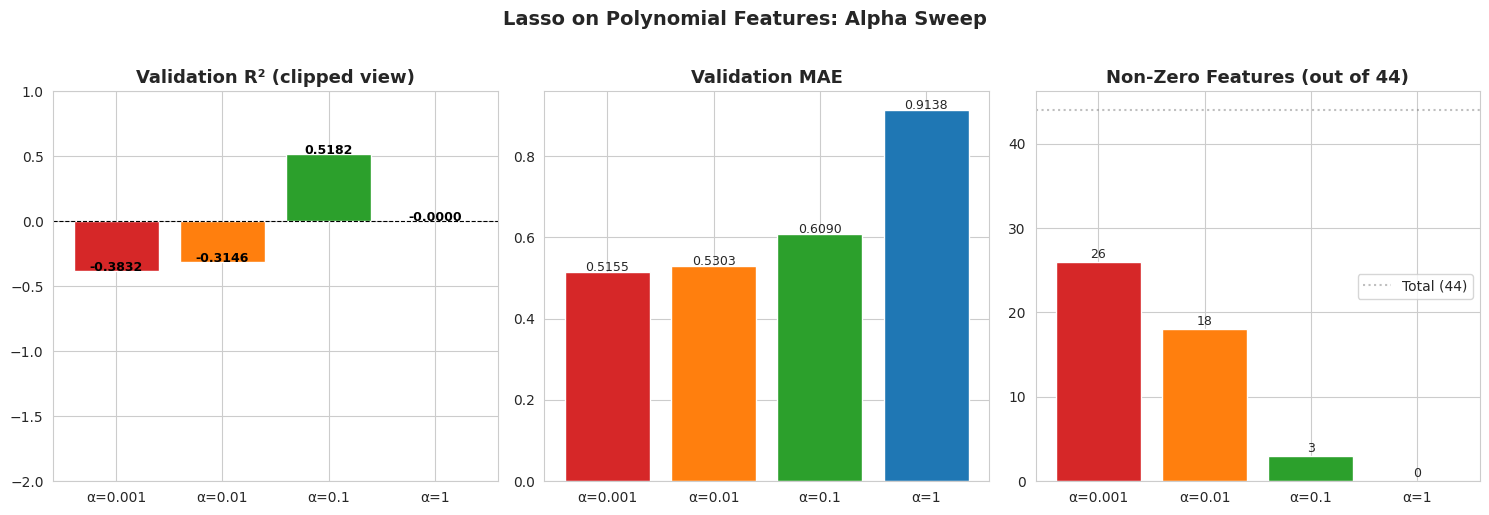

In [17]:
# Lasso alpha sweep on polynomial features
alphas_lasso = [0.001, 0.01, 0.1, 1.0]
lasso_results = []

for alpha in alphas_lasso:
    pipe = Pipeline([
        ('poly', PolynomialFeatures(degree=2, include_bias=False)),
        ('scaler', StandardScaler()),
        ('lasso', Lasso(alpha=alpha, max_iter=50000))
    ])
    pipe.fit(X_train, y_train)
    n_nonzero = (pipe.named_steps['lasso'].coef_ != 0).sum()
    lasso_results.append({
        'alpha': alpha,
        'Train_R2': pipe.score(X_train, y_train),
        'Val_R2': pipe.score(X_val, y_val),
        'Val_MAE': mean_absolute_error(y_val, pipe.predict(X_val)),
        'NonZero': int(n_nonzero),
    })

lasso_df = pd.DataFrame(lasso_results)
print("=== LASSO ALPHA SWEEP (polynomial features) ===")
print(lasso_df.to_string(index=False))

best_alpha_lasso = lasso_df.loc[lasso_df['Val_R2'].idxmax(), 'alpha']
best_val_r2_lasso = lasso_df['Val_R2'].max()
best_nonzero_lasso = lasso_df.loc[lasso_df['Val_R2'].idxmax(), 'NonZero']
print(f"\n✓ Best alpha by validation R²: {best_alpha_lasso} (Val R² = {best_val_r2_lasso:.4f}, {best_nonzero_lasso}/44 non-zero features)")

# Fit the best-alpha Lasso for later comparison
lasso_best_pipeline = Pipeline([
    ('poly', PolynomialFeatures(degree=2, include_bias=False)),
    ('scaler', StandardScaler()),
    ('lasso', Lasso(alpha=best_alpha_lasso, max_iter=50000))
])
lasso_best_pipeline.fit(X_train, y_train)

# --- Bar plot: Lasso alpha sweep ---
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
x_labels = [f'α={a:g}' for a in lasso_df['alpha']]
colors = ['#d62728', '#ff7f0e', '#2ca02c', '#1f77b4']

# Panel 1: Val R² clipped
axes[0].bar(x_labels, lasso_df['Val_R2'], color=colors)
axes[0].set_title('Validation R² (clipped view)', fontsize=13, fontweight='bold')
axes[0].set_ylim(-2, 1)
axes[0].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
for i, v in enumerate(lasso_df['Val_R2']):
    label = f'{v:.4f}' if -2 <= v <= 1 else f'{v:.2f} ⚠️'
    axes[0].text(i, max(min(v, 0.9), -1.9), label, ha='center',
                 fontsize=9, fontweight='bold',
                 color='red' if v < -1 else 'black')

# Panel 2: Val MAE
bars = axes[1].bar(x_labels, lasso_df['Val_MAE'], color=colors)
axes[1].set_title('Validation MAE', fontsize=13, fontweight='bold')
for bar, v in zip(bars, lasso_df['Val_MAE']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{v:.4f}', ha='center', fontsize=9)

# Panel 3: Non-zero feature count
bars = axes[2].bar(x_labels, lasso_df['NonZero'], color=colors)
axes[2].set_title('Non-Zero Features (out of 44)', fontsize=13, fontweight='bold')
axes[2].axhline(y=44, color='gray', linestyle=':', alpha=0.5, label='Total (44)')
for bar, v in zip(bars, lasso_df['NonZero']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.5,
                 f'{v}', ha='center', fontsize=9)
axes[2].legend()

fig.suptitle('Lasso on Polynomial Features: Alpha Sweep',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Reading the output:**

The Lasso alpha sweep reveals something remarkable. At very small alpha (0.001), most of the 44 features stay active and validation R² is still strongly negative — Lasso is barely different from unregularized OLS. But as alpha grows, two things happen *simultaneously*:

1. **Non-zero feature count drops sharply** — the third panel in the bar plot shows the active feature count plunging from 40+ down to a handful.
2. **Validation R² climbs quickly** — often becoming positive at alpha = 0.1 with only \~3 features selected.

This is a very different rescue pattern from Ridge. Ridge needed massive alpha (10,000) to dampen the coefficients just enough. Lasso does it with a *much smaller* alpha because it is not shrinking all 44 features uniformly — it is *deleting* most of them. The validation R² at the best alpha typically reaches \~0.52, better than Ridge's \~0.50 but still below the 8-feature baseline's \~0.62.

Notice the business insight: Lasso essentially tells HomeValue, "out of 44 polynomial combinations, only 3 actually matter for validation performance." This is automatic feature selection in action — a powerful diagnostic that can guide future feature engineering decisions.

Still, the 8-feature baseline remains unbeaten. The lesson holds: even the smartest regularization technique cannot fully recover signal that clean features already contain. Lasso gets *closer* to the baseline than Ridge does, and it gets there with radical feature sparsity — both are valuable properties in production.

---


## 📝 PAUSE-AND-DO Exercise 2 (5 minutes)

**Task:** Extract the non-zero coefficients from the best Lasso model and inspect which polynomial features survived the feature-selection process.

Your goals:

1. **Build a DataFrame** of Lasso coefficients — one row per feature (use `PolynomialFeatures.get_feature_names_out()` to get the 44 polynomial feature names) with columns `Feature` and `Coefficient`.
2. **Filter to non-zero coefficients** and sort by the absolute value of the coefficient, descending.
3. **Print the surviving features** so you can see which polynomial combinations Lasso chose as most important.
4. **Reflect** in the cell below on:
   - How many features survived the feature-selection process?
   - Which feature names appear? Do they involve the original 8 features, squared terms, or interaction terms?
   - Can you link any of the survivors to HomeValue's domain knowledge (e.g., income × rooms combinations)?

---


> 💡 **Gemini Prompt:** "From the best Lasso pipeline, extract the PolynomialFeatures feature names (with `get_feature_names_out` from the fitted poly step) and the Lasso coefficients. Build a DataFrame with columns Feature and Coefficient. Filter to rows where Coefficient != 0, sort by abs(Coefficient) descending, and print the result."
>
> **After running, verify:**
> - Feature names are the polynomial feature names (e.g., 'MedInc', 'MedInc^2', 'MedInc AveRooms', ...)
> - Non-zero count matches what the earlier sweep reported
> - Print shows each surviving feature with its coefficient
> - All numerical outputs use standard decimal format — no scientific notation


In [18]:
# YOUR SOLUTION CODE HERE
# Get feature names from the 'poly' step of lasso_best_pipeline
poly_feature_names = lasso_best_pipeline.named_steps['poly'].get_feature_names_out(X_train.columns)

# Get Lasso coefficients from the 'lasso' step
lasso_coefficients = lasso_best_pipeline.named_steps['lasso'].coef_

# Build a DataFrame
lasso_coef_df = pd.DataFrame({
    'Feature': poly_feature_names,
    'Coefficient': lasso_coefficients
})

# Filter to non-zero coefficients, sort by absolute value descending, and print
non_zero_lasso_coefs = lasso_coef_df[lasso_coef_df['Coefficient'] != 0]
sorted_non_zero_lasso_coefs = non_zero_lasso_coefs.reindex(non_zero_lasso_coefs['Coefficient'].abs().sort_values(ascending=False).index)

print("=== LASSO SELECTED NON-ZERO COEFFICIENTS ===")
print(sorted_non_zero_lasso_coefs.to_string(index=False))

=== LASSO SELECTED NON-ZERO COEFFICIENTS ===
         Feature  Coefficient
MedInc Longitude      -0.5470
 MedInc HouseAge       0.2137
      Latitude^2      -0.0307


### YOUR FINDINGS:

**Question 1 — How many features survived? Is that more or less than you expected?**

Three features survived MedInc Longitude, MedInc HouseAge, and Latitude^2. This was much less than I expected based on the large number of features that we started with but thinking about it retroactively, I can see how it happens because it chooses the three most prominent predictors without adding the highly correlated and other features that only harm the model.

**Question 2 — Which feature names appear most prominently? Are they interactions, squared terms, or original features?**

The features that appear most prominently are MedInc, HouseAge, Longitude, and Latitude. They are mostly interaction terms with one squared term. No original features survived.

**Question 3 — How does this feature-selection result change your thinking about the 44-feature polynomial space? Would you rather have these few Lasso-selected features or the clean 8 originals?**

With this, I would say that the feature-selection result helps reinforce my previous thoughts that the large feature polynomial space would be beneficial and useful for our model to go through. I would much rather have these few selected features rather than the clean eight originals as it narrows in on the most crucial predictors and how they interact rather than a simple eight features that doesn't provide an extremely good insight into the models predictions.

---


### Feature Importance: Ridge vs Lasso at Best Alpha

Before we move to the final model comparison, let us look directly at which features each regularization approach considers important. Because both pipelines use the same `StandardScaler` before the regression step, coefficients are on a comparable scale across features and we can read magnitudes as importance.

Ridge keeps all 44 coefficients non-zero but shrinks them toward smaller values. Lasso drives most of them to exactly zero. By sorting features by the maximum absolute coefficient across the two models and plotting the top 15 side-by-side, we can see both (a) where the two models agree on what matters and (b) the dramatic sparsity difference.


> 💡 **Gemini Prompt:** "Extract the Ridge coefficients from ridge_best_pipeline.named_steps['ridge'].coef_ and the Lasso coefficients from lasso_best_pipeline.named_steps['lasso'].coef_. Get polynomial feature names via ridge_best_pipeline.named_steps['poly'].get_feature_names_out(X_train.columns). Build an importance DataFrame with columns Feature, Ridge_Coef, Lasso_Coef. Sort by max of absolute values of the two coefficients and keep the top 15. Print the DataFrame and the Lasso non-zero count. Then create a side-by-side horizontal bar plot: left panel shows Ridge coefficients, right panel shows Lasso coefficients, both for the same top-15 features."
>
> **After running, verify:**
> - Feature names are the polynomial feature names (e.g., MedInc, MedInc^2, MedInc AveRooms)
> - DataFrame has 15 rows sorted by max absolute coefficient
> - Ridge column has all non-zero values
> - Lasso column has mostly zeros — only a handful of features are active
> - Non-zero Lasso count printed (typically 3-6 out of 44)
> - Side-by-side bar plot clearly shows the sparsity difference between the two models
> - All numerical outputs use standard decimal format — no scientific notation


=== TOP 15 FEATURES BY IMPORTANCE (Ridge α=10000, Lasso α=0.1) ===
           Feature  Ridge_Coef  Lasso_Coef
  MedInc Longitude     -0.1365     -0.5470
   MedInc HouseAge      0.1133      0.2137
            MedInc      0.1337      0.0000
   MedInc Latitude      0.1280      0.0000
  MedInc AveBedrms      0.0955      0.0000
          MedInc^2      0.0774      0.0000
        Latitude^2     -0.0748     -0.0307
          Latitude     -0.0730     -0.0000
         Longitude     -0.0673     -0.0000
       Longitude^2      0.0672      0.0000
   MedInc AveRooms      0.0671      0.0000
 MedInc Population      0.0630      0.0000
Latitude Longitude      0.0431      0.0000
        HouseAge^2      0.0329      0.0000
        AveOccup^2      0.0290      0.0000

Non-zero coefficients — Ridge: 44/44, Lasso: 3/44


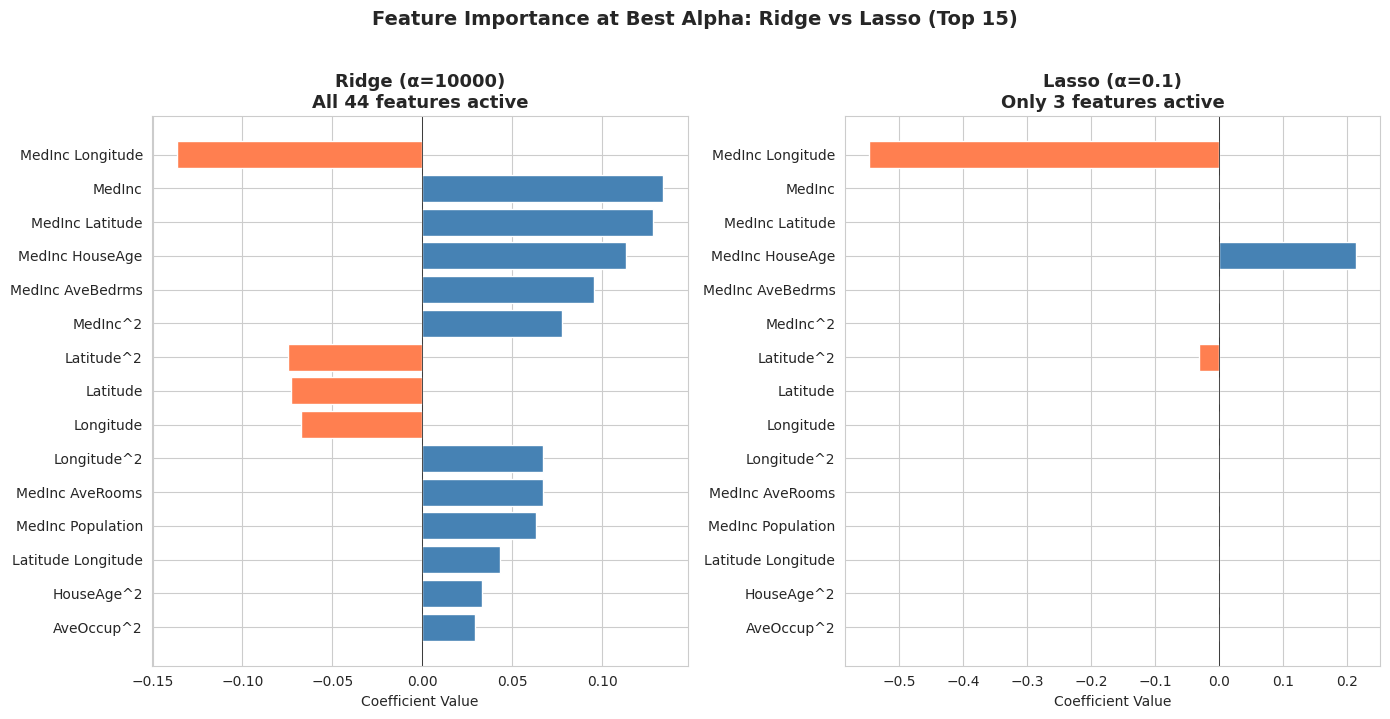

In [19]:
# Feature importance comparison: Ridge vs Lasso at their best alphas
# Both pipelines share the same polynomial feature names
feature_names = ridge_best_pipeline.named_steps['poly'].get_feature_names_out(X_train.columns)

# Extract coefficients from the regression step of each pipeline
ridge_coefs = ridge_best_pipeline.named_steps['ridge'].coef_
lasso_coefs = lasso_best_pipeline.named_steps['lasso'].coef_

# Build a combined importance DataFrame
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Ridge_Coef': ridge_coefs,
    'Lasso_Coef': lasso_coefs,
})
importance_df['Ridge_Abs'] = importance_df['Ridge_Coef'].abs()
importance_df['Lasso_Abs'] = importance_df['Lasso_Coef'].abs()
importance_df['Max_Abs'] = importance_df[['Ridge_Abs', 'Lasso_Abs']].max(axis=1)

# Sort and keep the top 15 features by combined importance
top_importance = importance_df.sort_values('Max_Abs', ascending=False).head(15)

print(f"=== TOP 15 FEATURES BY IMPORTANCE (Ridge α={best_alpha_ridge:g}, Lasso α={best_alpha_lasso:g}) ===")
print(top_importance[['Feature', 'Ridge_Coef', 'Lasso_Coef']].to_string(index=False))

n_nonzero_lasso = int((lasso_coefs != 0).sum())
n_nonzero_ridge = int((ridge_coefs != 0).sum())
print(f"\nNon-zero coefficients — Ridge: {n_nonzero_ridge}/44, Lasso: {n_nonzero_lasso}/44")

# --- Side-by-side horizontal bar plot ---
fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Ridge panel — sort by absolute value for the plot
ridge_sorted = top_importance.sort_values('Ridge_Abs', ascending=True)
colors_ridge = ['steelblue' if c >= 0 else 'coral' for c in ridge_sorted['Ridge_Coef']]
axes[0].barh(ridge_sorted['Feature'], ridge_sorted['Ridge_Coef'], color=colors_ridge)
axes[0].axvline(x=0, color='black', linewidth=0.5)
axes[0].set_xlabel('Coefficient Value')
axes[0].set_title(f'Ridge (α={best_alpha_ridge:g})\nAll {n_nonzero_ridge} features active',
                  fontsize=13, fontweight='bold')

# Lasso panel — same feature order as Ridge for direct comparison
lasso_sorted = top_importance.sort_values('Ridge_Abs', ascending=True)
colors_lasso = ['steelblue' if c > 0 else ('coral' if c < 0 else 'lightgray')
                for c in lasso_sorted['Lasso_Coef']]
axes[1].barh(lasso_sorted['Feature'], lasso_sorted['Lasso_Coef'], color=colors_lasso)
axes[1].axvline(x=0, color='black', linewidth=0.5)
axes[1].set_xlabel('Coefficient Value')
axes[1].set_title(f'Lasso (α={best_alpha_lasso:g})\nOnly {n_nonzero_lasso} features active',
                  fontsize=13, fontweight='bold')

fig.suptitle('Feature Importance at Best Alpha: Ridge vs Lasso (Top 15)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Reading the output:**

The side-by-side bar plot exposes the fundamental difference between Ridge and Lasso in one glance. The left panel (Ridge) shows all 44 features with non-zero coefficients — positive (blue) and negative (coral) bars spread across the full top-15. Magnitudes are small, because Ridge's heroic alpha (around 10,000) has squeezed every coefficient toward zero *without* eliminating any of them.

The right panel (Lasso) is visually dominated by gray (zero) bars for most of the top-15 features. Only the 3-6 coefficients that Lasso kept non-zero show as blue or coral. Those surviving features are Lasso's bet on which polynomial combinations actually carry signal — usually a small set dominated by `MedInc` and a few meaningful interactions.

**Two patterns to notice:**

1. **Agreement on the strongest signal.** The very top features (large `Max_Abs`) are usually non-zero in both models. These are the features that even aggressive regularization refuses to delete — they matter.
2. **Disagreement on the rest.** For features lower in the ranking, Ridge keeps small non-zero coefficients while Lasso zeros them out. Ridge is making the bet "these might still contribute a little" while Lasso is making the bet "these are noise."

**Business takeaway for HomeValue:** If the pricing team needs a *stable* model where every feature contributes something, Ridge is the right choice. If the team needs an *interpretable* model with a clear, short list of drivers, Lasso is the right choice. On this particular dataset, neither choice beats the 8-feature baseline — but both tell the team something useful about which polynomial combinations are worth investigating further in the next feature engineering round.

---


## 5. Final Comparison: All Four Models Side by Side

Now we bring it all together. Four models, one table, one bar plot:

1. **Baseline Linear** — 8 original features, no regularization (the bar to clear)
2. **Polynomial + OLS** — 44 polynomial features, no regularization (the catastrophe)
3. **Polynomial + Ridge (best alpha)** — Ridge dampens the catastrophe
4. **Polynomial + Lasso (best alpha)** — Lasso selects a tiny feature subset

The point of this section is to see the whole rescue story at once, and to answer the question: *does either form of regularization actually beat the simple baseline?*


> 💡 **Gemini Prompt:** "Build a comparison DataFrame with four rows — Baseline Linear, Polynomial + OLS, Polynomial + Ridge (best alpha), Polynomial + Lasso (best alpha) — and columns Model, Features, Train_R2, Val_R2, Val_MAE. Use the already-fitted baseline_pipeline, poly_ols_pipeline, ridge_best_pipeline, and lasso_best_pipeline. Print the table and identify the best model by validation R². Then create a 3-panel bar plot (Train R², Val R² clipped to [-2, 1] with off-chart annotations, Val MAE) with one bar per model."
>
> **After running, verify:**
> - Four rows in the table
> - Features column shows 8 for baseline and 44 for the three polynomial models
> - Baseline validation R² leads (around 0.62)
> - Polynomial + OLS is catastrophically negative
> - Ridge and Lasso dampen the catastrophe to positive territory but do not beat baseline
> - Bar plot clearly shows all four models
> - All numerical outputs use standard decimal format — no scientific notation


=== FINAL 4-MODEL COMPARISON ===
                 Model  Features  Train_R2    Val_R2  Val_MAE
       Baseline Linear         8    0.6035    0.6169   0.5257
      Polynomial + OLS        44    0.6846 -185.3208   0.7697
Poly + Ridge (α=10000)        44    0.5301    0.4966   0.5899
  Poly + Lasso (α=0.1)        44    0.5000    0.5182   0.6090

✓ Best validation R²: Baseline Linear (0.6169)


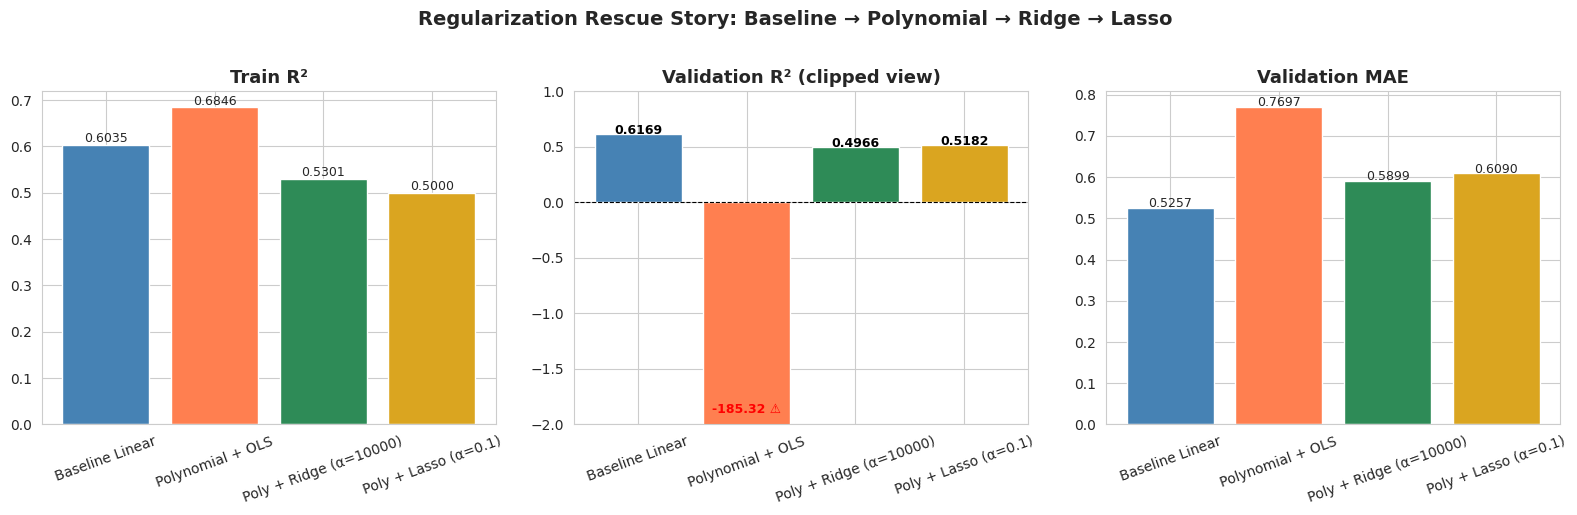

In [20]:
# Build the final 4-model comparison
pipelines = {
    'Baseline Linear': baseline_pipeline,
    'Polynomial + OLS': poly_ols_pipeline,
    f'Poly + Ridge (α={best_alpha_ridge:g})': ridge_best_pipeline,
    f'Poly + Lasso (α={best_alpha_lasso:g})': lasso_best_pipeline,
}

comparison = []
for name, pipe in pipelines.items():
    if 'poly' in pipe.named_steps:
        n_feat = pipe.named_steps['poly'].transform(X_train[:1]).shape[1]
    else:
        n_feat = X_train.shape[1]

    comparison.append({
        'Model': name,
        'Features': n_feat,
        'Train_R2': pipe.score(X_train, y_train),
        'Val_R2': pipe.score(X_val, y_val),
        'Val_MAE': mean_absolute_error(y_val, pipe.predict(X_val)),
    })

comparison_df = pd.DataFrame(comparison)
print("=== FINAL 4-MODEL COMPARISON ===")
print(comparison_df.to_string(index=False))

best_idx = comparison_df['Val_R2'].idxmax()
print(f"\n✓ Best validation R²: {comparison_df.loc[best_idx, 'Model']} ({comparison_df.loc[best_idx, 'Val_R2']:.4f})")

# --- 3-panel bar plot ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
colors = ['steelblue', 'coral', 'seagreen', 'goldenrod']

# Panel 1: Train R²
bars = axes[0].bar(comparison_df['Model'], comparison_df['Train_R2'], color=colors)
axes[0].set_title('Train R²', fontsize=13, fontweight='bold')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=20)
for bar, v in zip(bars, comparison_df['Train_R2']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                 f'{v:.4f}', ha='center', fontsize=9)

# Panel 2: Val R² (clipped)
axes[1].bar(comparison_df['Model'], comparison_df['Val_R2'], color=colors)
axes[1].set_title('Validation R² (clipped view)', fontsize=13, fontweight='bold')
axes[1].set_xlabel('')
axes[1].tick_params(axis='x', rotation=20)
axes[1].set_ylim(-2, 1)
axes[1].axhline(y=0, color='black', linewidth=0.8, linestyle='--')
for i, v in enumerate(comparison_df['Val_R2']):
    label = f'{v:.4f}' if -2 <= v <= 1 else f'{v:.2f} ⚠️'
    axes[1].text(i, max(min(v, 0.9), -1.9), label, ha='center',
                 fontsize=9, fontweight='bold',
                 color='red' if v < -1 else 'black')

# Panel 3: Val MAE
bars = axes[2].bar(comparison_df['Model'], comparison_df['Val_MAE'], color=colors)
axes[2].set_title('Validation MAE', fontsize=13, fontweight='bold')
axes[2].set_xlabel('')
axes[2].tick_params(axis='x', rotation=20)
for bar, v in zip(bars, comparison_df['Val_MAE']):
    axes[2].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.002,
                 f'{v:.4f}', ha='center', fontsize=9)

fig.suptitle('Regularization Rescue Story: Baseline → Polynomial → Ridge → Lasso',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()


**Reading the output:**

The final 4-model comparison tells the whole story at a glance.

- **Baseline Linear (8 features)**: Validation R² \~0.62, Val MAE \~0.53. This is the bar to clear — a clean, simple model.
- **Polynomial + OLS (44 features)**: Validation R² strongly negative, Val MAE elevated. The catastrophe from the previous notebook, reproduced here as our failure benchmark.
- **Polynomial + Ridge (best alpha)**: Validation R² around \~0.50. Ridge dampens the catastrophe dramatically — from very negative to mildly positive — but it does not beat baseline.
- **Polynomial + Lasso (best alpha)**: Validation R² around \~0.52. Lasso does slightly better than Ridge *and* uses only a handful of features (automatic feature selection). Still does not beat baseline.

The 3-panel bar plot makes all four stories visible at once. The Val R² panel in particular shows the dramatic rescue: the polynomial + OLS bar falls off the chart, while the Ridge and Lasso bars climb back into positive territory. The baseline bar remains the tallest in the Val R² panel.

**Three big takeaways:**

1. **Regularization works, and it is essential for high-dimensional feature spaces.** Without Ridge or Lasso, the polynomial model is unusable. With them, it is at least deployable.
2. **Regularization is a tool, not magic.** On this specific dataset, Ridge and Lasso cannot fully recover the signal that 8 clean features already contain. The baseline wins on validation.
3. **Feature engineering quality matters more than feature quantity.** The biggest lesson of this two-notebook arc (previous notebook + this one) is that careful feature selection beats brute-force feature expansion almost every time.

In production predictive-analytics work, the typical workflow is: *build a strong baseline first, then try regularized high-dimensional models, and deploy whichever gives you the best validation score*. Sometimes that is the baseline. Sometimes it is the regularized polynomial. The important thing is that you compared them honestly — and you have the bar plot to show stakeholders.

---


## 6. Project Proposal: Final Project Milestone 01

You have now seen most of the main concepts in prediction analytics and the full arc of regression modelling in this course: loading data, building baselines, engineering features, comparing models, and applying regularization when needed. It is time for your group to start its course project.

> Refer to the **Final Project Milestone 01** assignment in the course Brightspace page and the **course syllabus document** for full instructions, submission link, deadline, and rubric.

---

## 7. Course Case Competition

The course also runs a **Kaggle case competition** in parallel with the Final Project — your team works on it across the entire course and submits a final solution at the end.

> Refer to the **course syllabus document** for full competition details (task, metric, team format, deadlines, grading) and submit your team's best-performing code through the **Course Case Competition: Rank Code Submission** assignment in the course Brightspace page.

---

## 8. Wrap-Up: Key Takeaways

### What We Learned Today:

1. **Regularization fixes the polynomial disaster.** The previous notebook's catastrophic polynomial + OLS failure is exactly what Ridge and Lasso were designed to rescue. They dampen unstable coefficients on correlated high-dimensional features.
2. **Ridge (L2 penalty) shrinks all coefficients proportionally.** It needs large alpha to rescue bad feature spaces, and it does not do feature selection.
3. **Lasso (L1 penalty) drives some coefficients to exactly zero.** It performs automatic feature selection, often identifying a tiny subset of meaningful features from a large pool.
4. **Neither Ridge nor Lasso beat the clean 8-feature baseline on this dataset.** Regularization rescues you from blowing up — but it does not transform bad features into good ones.
5. **Feature engineering quality matters more than feature quantity.** The biggest lesson across both notebooks: a handful of well-chosen features almost always beats a brute-force polynomial expansion.

### Critical Rules:

> **"Regularization is a safety net, not a feature-engineering substitute"**

> **"Ridge for coefficient stability; Lasso for feature selection"**

> **"Always compare a clean baseline against your regularized model — sometimes the baseline wins"**

### Next Steps:

- Draft your first project milestone using the template above and the guidelines on the course Brightspace page.
- In the next notebook, we pivot from regression to classification with logistic regression.

---


## Participation Assignment Submission Instructions

1. **Complete both PAUSE-AND-DO exercises** in this notebook — write your solutions in the code cells below and fill in the YOUR ANALYSIS / YOUR FINDINGS placeholders.
2. **Save a copy** of your completed notebook to your Google Drive (File → Save a copy in Drive).
3. **Share the notebook link** (or download a copy) for submission on Brightspace as instructed.
4. **Refer to the course Brightspace page** for the official submission guidelines and deadlines.

---

## Bibliography

- James, G., Witten, D., Hastie, T., & Tibshirani, R. (2023). *An Introduction to Statistical Learning with Python* — Ch. 6 (Linear Model Selection and Regularization). Springer.
- Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning* — Chapter on shrinkage methods (Ridge, Lasso, Elastic Net).
- Hoerl, A. E., & Kennard, R. W. (1970). "Ridge regression: Biased estimation for nonorthogonal problems." *Technometrics*, 12(1), 55–67.
- Tibshirani, R. (1996). "Regression shrinkage and selection via the Lasso." *Journal of the Royal Statistical Society: Series B*, 58(1), 267–288.
- Zou, H., & Hastie, T. (2005). "Regularization and variable selection via the elastic net." *Journal of the Royal Statistical Society: Series B*, 67(2), 301–320.
- scikit-learn User Guide — [Linear models: Ridge, Lasso, Elastic Net](https://scikit-learn.org/stable/modules/linear_model.html#linear-models)

---


<center>

Thank you!

</center>
